In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
plt.rcParams.update({"font.size": 12, "figure.figsize": (6, 4)})
np.random.seed(2807)
print("pymc", pm.__version__, "| numpy", np.__version__)

/Users/aidanbehmer/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


pymc 5.28.5 | numpy 2.4.6


No changes from the tutorial

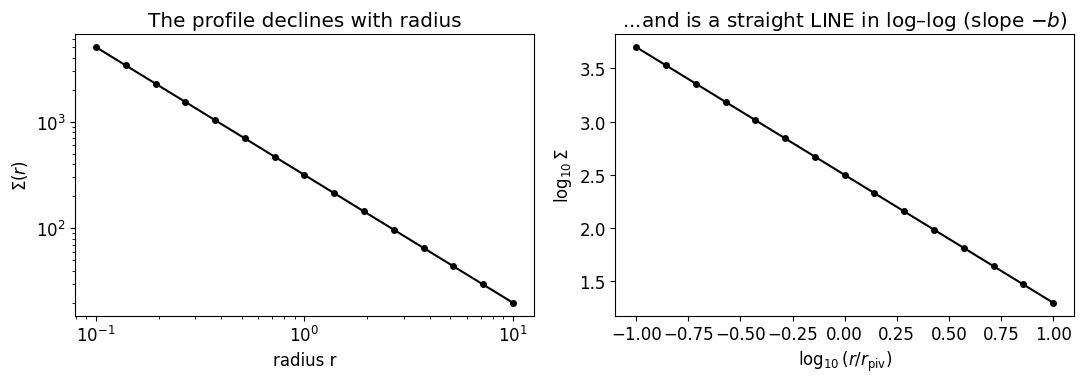

In [2]:
radii = np.logspace(-1, 1, 15)            # 15 radial bins, r = 0.1 .. 10 (e.g. arcmin or Mpc)
r_pivot = 1.0
log_r = np.log10(radii / r_pivot)         # the line's x-axis

def profile_model(theta):
    # log10 Sigma(r) = a - b log10(r/r_piv).  theta = (amplitude a, slope b).
    a, b = theta
    return a - b * log_r

a_true, b_true = 2.5, 1.2                  # one example cluster
log_sigma_true = profile_model((a_true, b_true))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(radii, 10**log_sigma_true, "k-o", ms=4)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("radius r"); ax[0].set_ylabel(r"$\Sigma(r)$")
ax[0].set_title("The profile declines with radius")
ax[1].plot(log_r, log_sigma_true, "k-o", ms=4)
ax[1].set_xlabel(r"$\log_{10}(r/r_{\rm piv})$"); ax[1].set_ylabel(r"$\log_{10}\Sigma$")
ax[1].set_title("...and is a straight LINE in log–log (slope $-b$)")
plt.tight_layout(); plt.show()

No Changes

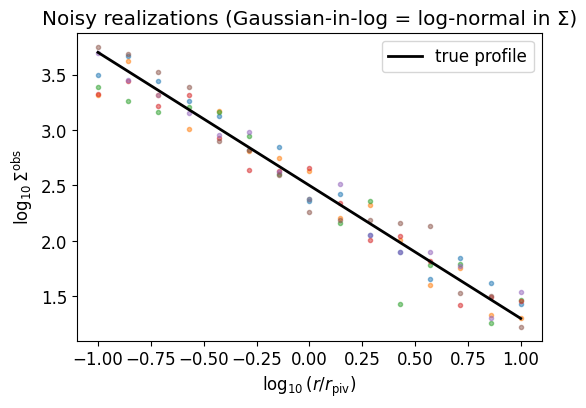

In [3]:
noise_dex = 0.15                                   # per-bin 1-sigma noise in log10 Sigma ("dex")
def observe(theta, sigma=noise_dex):
    # one noisy profile (a data VECTOR of length N_r)
    return profile_model(theta) + sigma * np.random.randn(len(radii))

plt.figure()
for _ in range(6):                                # several noisy realizations of the SAME cluster
    plt.plot(log_r, observe((a_true, b_true)), ".", alpha=0.5)
plt.plot(log_r, log_sigma_true, "k-", lw=2, label="true profile")
plt.xlabel(r"$\log_{10}(r/r_{\rm piv})$"); plt.ylabel(r"$\log_{10}\Sigma^{\rm obs}$")
plt.title("Noisy realizations (Gaussian-in-log = log-normal in Σ)"); plt.legend(); plt.show()

data_one = observe((a_true, b_true))               # the ONE cluster we will fit next

No Changes

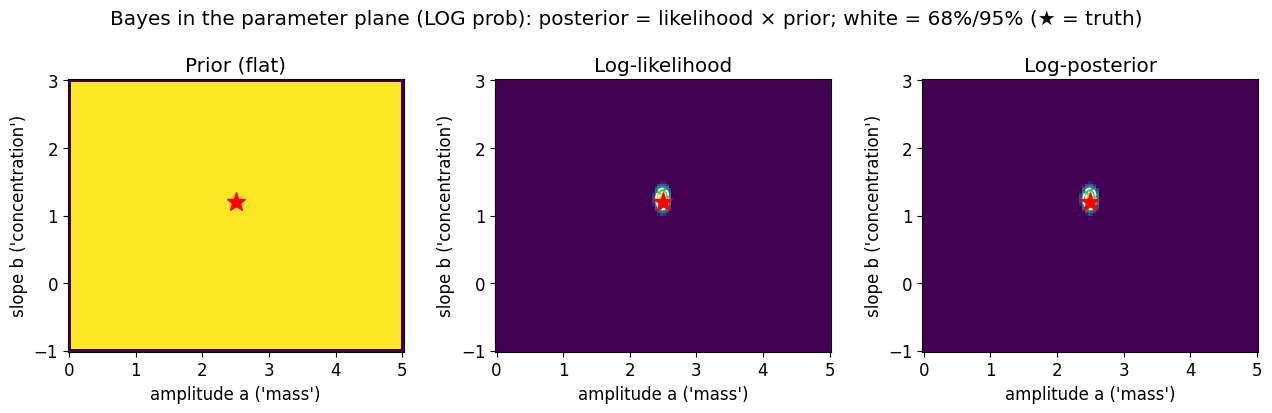

In [4]:
def log_likelihood(theta, d, sigma=noise_dex):
    resid = d - profile_model(theta)
    return -0.5 * np.sum(resid**2 / sigma**2)

A_LO, A_HI, B_LO, B_HI = 0.0, 5.0, -1.0, 3.0       # the flat-prior box for (a, b)
def log_prior(theta):
    a, b = theta
    return 0.0 if (A_LO < a < A_HI and B_LO < b < B_HI) else -np.inf

def log_posterior(theta, d, sigma=noise_dex):
    lp = log_prior(theta)
    return -np.inf if not np.isfinite(lp) else lp + log_likelihood(theta, d, sigma)

# Evaluate prior / likelihood / posterior on a grid over the (a,b) plane.
agrid = np.linspace(A_LO, A_HI, 120); bgrid = np.linspace(B_LO, B_HI, 120)
AA, BB = np.meshgrid(agrid, bgrid, indexing="ij")
model_cube = AA[..., None] - BB[..., None] * log_r          # predicted profile at every (a,b)
chi2 = np.sum((data_one - model_cube)**2 / noise_dex**2, axis=-1)
# Work in LOG probability -- the linear likelihood is far too sharply peaked to see as a color map.
loglike  = -0.5 * (chi2 - chi2.min())                       # log-likelihood (relative to its peak)
logprior = np.where((AA > A_LO) & (AA < A_HI) & (BB > B_LO) & (BB < B_HI), 0.0, -50.0)  # flat prior (log)
logpost  = loglike + logprior; logpost -= logpost.max()     # log posterior = log likelihood + log prior
levels = [-3.09, -1.15]                                     # 95% / 68% credible (Delta 2 lnL = 6.18, 2.30)

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
panels = [("Prior (flat)",   np.clip(logprior, -8, 0),               None),
          ("Log-likelihood", np.clip(loglike - loglike.max(), -8, 0), loglike - loglike.max()),
          ("Log-posterior",  np.clip(logpost, -8, 0),                 logpost)]
for axi, (title, shade, cont) in zip(ax, panels):
    axi.pcolormesh(AA, BB, shade, shading="auto", cmap="viridis")
    if cont is not None: axi.contour(AA, BB, cont, levels=levels, colors="white", linewidths=1.2)
    axi.plot(a_true, b_true, "r*", ms=14)
    axi.set_xlabel("amplitude a ('mass')"); axi.set_ylabel("slope b ('concentration')"); axi.set_title(title)
fig.suptitle("Bayes in the parameter plane (LOG prob): posterior = likelihood × prior; white = 68%/95% (★ = truth)")
plt.tight_layout(); plt.show()

In [12]:

with pm.Model() as model:

    # priors
    a = pm.Uniform("a", lower=A_LO, upper=A_HI)
    b = pm.Uniform("b", lower=B_LO, upper=B_HI)

    # deterministic profile
    mu = a - b * log_r

    # likelihood
    pm.Normal(
        "obs",
        mu=mu,
        sigma=noise_dex,
        observed=data_one,
    )

    trace = pm.sample(
        draws=2000,
        tune=500,
        chains=4,
        target_accept=0.9,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 1 seconds.


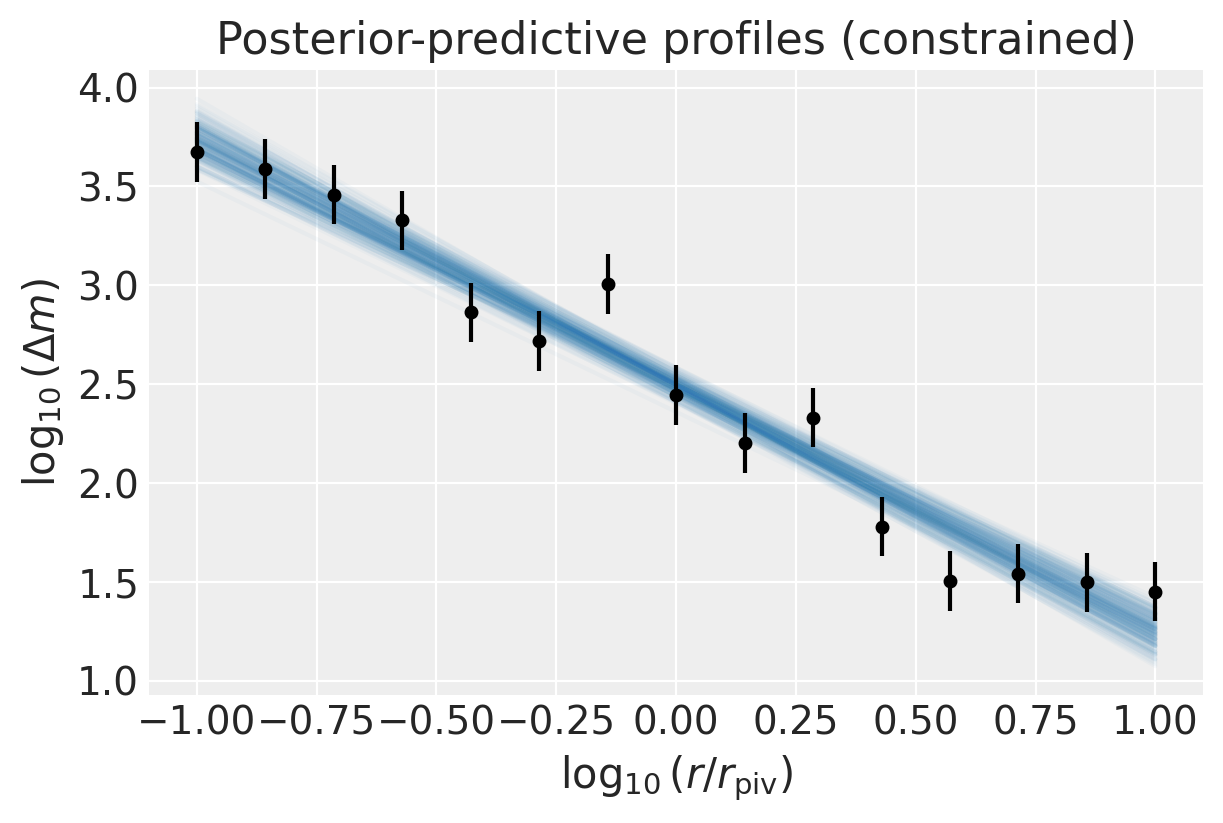

a = 2.493178549633866 +/- 0.03861955241289557
b = 1.245789624277993 +/- 0.06255346410086665


In [22]:
posterior = trace.posterior

a_samples = posterior["a"].values.flatten()
b_samples = posterior["b"].values.flatten()

fig, ax = plt.subplots(figsize=(6,4))

for i in np.random.choice(len(a_samples), 200, replace=False):
    mu_i = a_samples[i] - b_samples[i] * log_r

    ax.plot(
        log_r,
        mu_i,
        color="tab:blue",
        alpha=0.03
    )

ax.errorbar(
    log_r,
    data_one,
    yerr=noise_dex,
    fmt="ko",
    ms=4
)
plt.title("Posterior-predictive profiles (constrained)"); plt.xlabel(r"$\log_{10}(r/r_{\rm piv})$"); plt.ylabel(r"$\log_{10}(\Delta m)$")
plt.show()
print("a =", a_samples.mean(), "+/-", a_samples.std())
print("b =", b_samples.mean(), "+/-", b_samples.std())


Initializing NUTS using jitter+adapt_diag...


TRUE hyper-parameters:  population mean = [2.5 1.2]   intrinsic scatter = [0.25 0.3 ]


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_a, mu_b, sigma_a, sigma_b, a, b]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


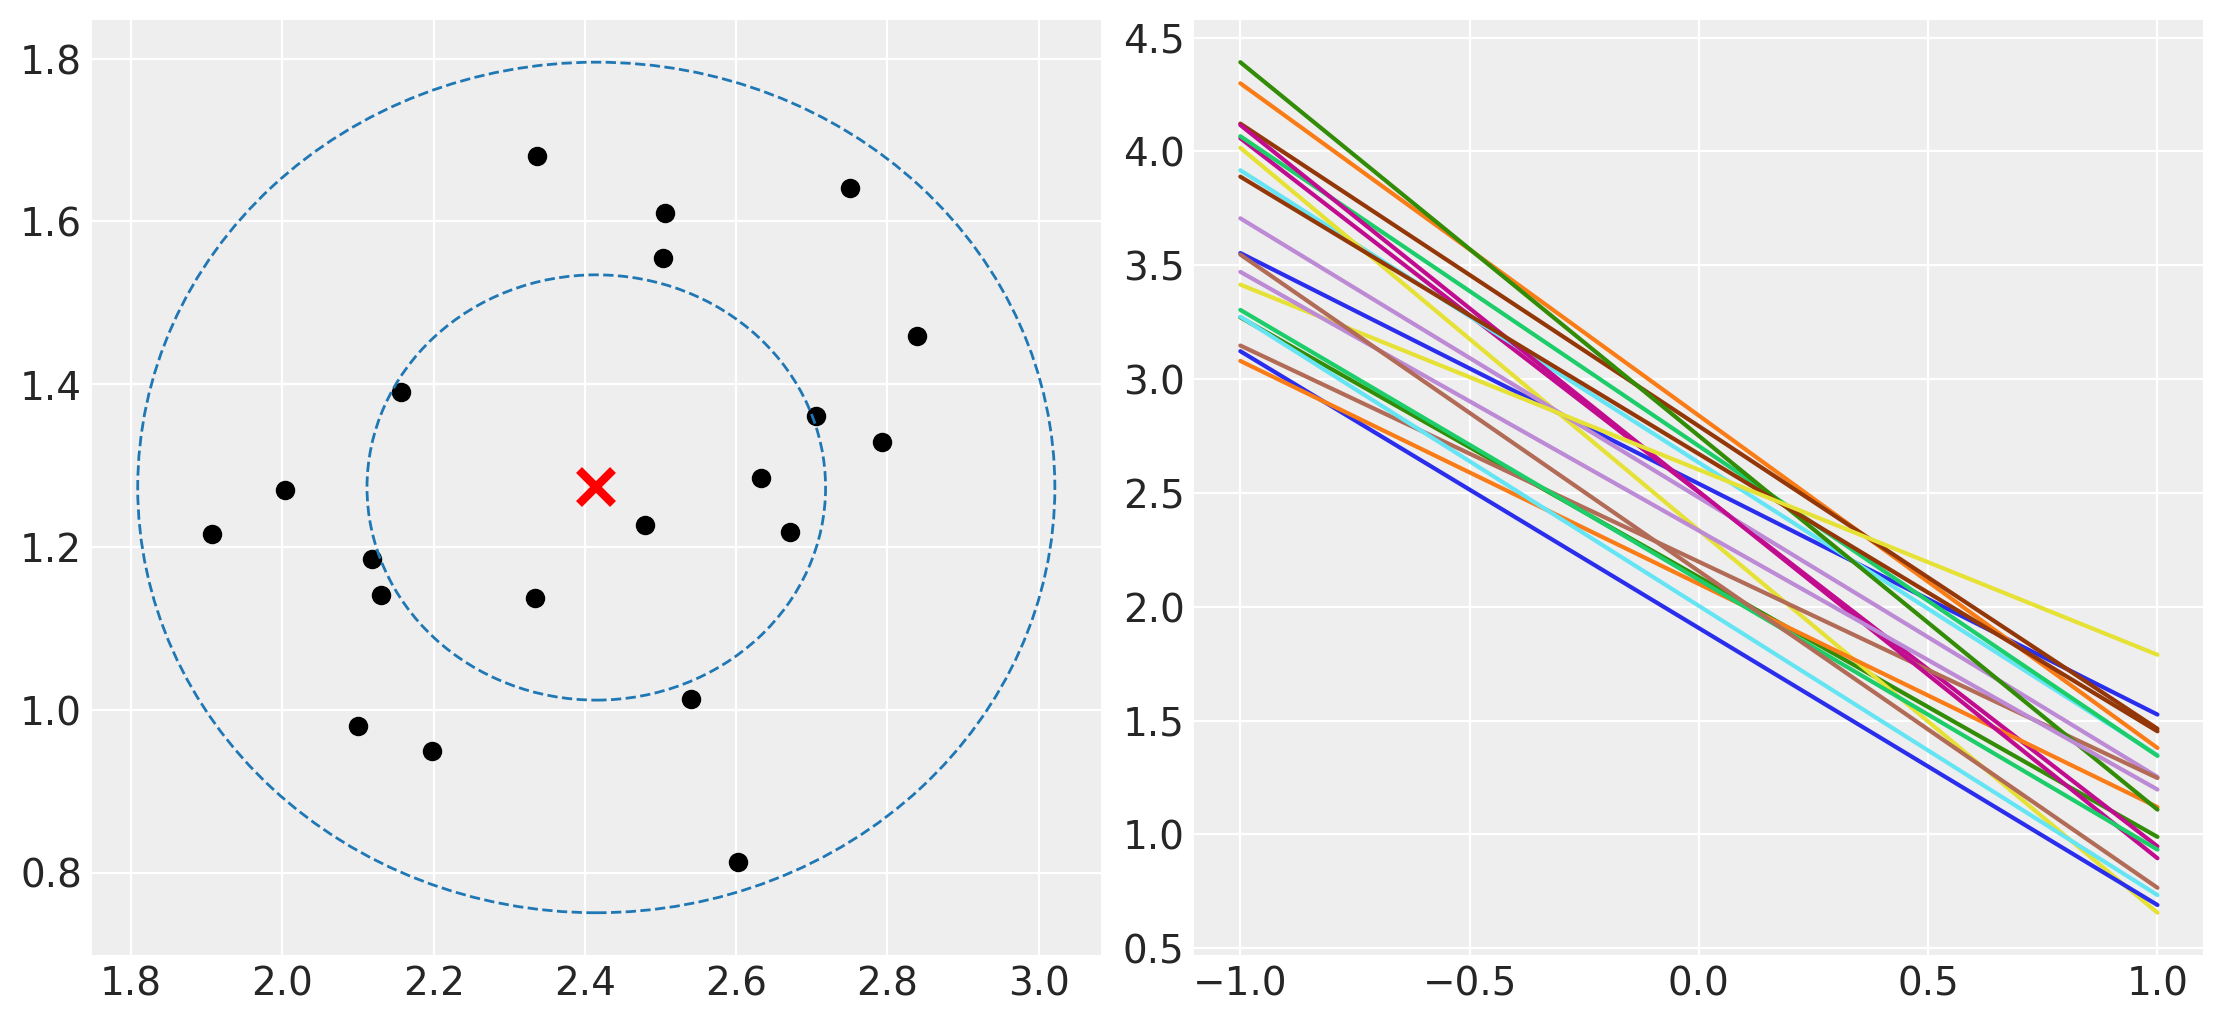

In [26]:
n_clusters = 20
mu_pop = np.array([2.50, 1.20])      # TRUE population mean of (amplitude, slope)
s_pop  = np.array([0.25, 0.30])      # TRUE intrinsic scatter (cluster-to-cluster)
print("TRUE hyper-parameters:  population mean =", mu_pop, "  intrinsic scatter =", s_pop)

theta_true = mu_pop + s_pop * np.random.randn(n_clusters, 2)         # each cluster's true (a,b)
profiles   = np.array([profile_model(theta_true[j]) + noise_dex*np.random.randn(len(radii))
                       for j in range(n_clusters)])                  # their noisy profiles

with pm.Model() as hierarchical_model:

    # population mean
    mu_a = pm.Normal("mu_a", mu=2.5, sigma=1)
    mu_b = pm.Normal("mu_b", mu=1.2, sigma=1)

    # population scatter
    sigma_a = pm.HalfNormal("sigma_a", sigma=0.5)
    sigma_b = pm.HalfNormal("sigma_b", sigma=0.5)

    # cluster-level parameters
    a = pm.Normal(
        "a",
        mu=mu_a,
        sigma=sigma_a,
        shape=n_clusters
    )

    b = pm.Normal(
        "b",
        mu=mu_b,
        sigma=sigma_b,
        shape=n_clusters
    )

    # expected profiles
    mu_profile = (
        a[:, None]
        - b[:, None] * log_r[None, :]
    )

    # likelihood
    pm.Normal(
        "obs",
        mu=mu_profile,
        sigma=noise_dex,
        observed=profiles
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9
    )
    import arviz as az
mu_a_post = trace.posterior["mu_a"].values.mean()
mu_b_post = trace.posterior["mu_b"].values.mean()

sig_a_post = trace.posterior["sigma_a"].values.mean()
sig_b_post = trace.posterior["sigma_b"].values.mean()

a_post = trace.posterior["a"].values.mean(axis=(0,1))
b_post = trace.posterior["b"].values.mean(axis=(0,1))

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(1,2,figsize=(11,5))

ax[0].scatter(a_post, b_post, c="k")

for nsig in [1,2]:
    ax[0].add_patch(
        Ellipse(
            (mu_a_post, mu_b_post),
            2*nsig*sig_a_post,
            2*nsig*sig_b_post,
            fill=False,
            ls="--",
            color="tab:blue"
        )
    )

ax[0].plot(
    mu_a_post,
    mu_b_post,
    "rx",
    ms=12,
    mew=3
)


for i in range(n_clusters):

    profile_i = (
        a_post[i]
        - b_post[i]*log_r
    )

    ax[1].plot(log_r, profile_i)

plt.show()

In [69]:
def fits(nc):
    n_clusters=nc
    theta_true = mu_pop + s_pop * np.random.randn(n_clusters, 2)   
    profiles   = np.array([profile_model(theta_true[j]) + noise_dex*np.random.randn(len(radii))
                       for j in range(n_clusters)])
    median_profile = np.median(profiles, axis=0)
    sigma_tilde_sq = (np.pi/2) * noise_dex**2 / n_clusters
    def with_prior(loglike):
        return lambda th: loglike(th) if np.isfinite(log_prior(th)) else -np.inf

    ll_JtF   = lambda th: -0.5 * np.sum((median_profile - profile_model(th))**2 / sigma_tilde_sq)
    ll_FtJ   = lambda th: -(1/(2*n_clusters)) * np.sum((profiles - profile_model(th))**2 / noise_dex**2)
    ll_joint = lambda th: -0.5 * np.sum((profiles - profile_model(th))**2 / noise_dex**2)
    with pm.Model() as jtf_model:

        a = pm.Uniform("a", lower=A_LO, upper=A_HI)
        b = pm.Uniform("b", lower=B_LO, upper=B_HI)

        mu = a - b*log_r

        pm.Normal(
            "obs",
            mu=mu,
            sigma=np.sqrt(sigma_tilde_sq),
            observed=median_profile,
        )

        trace_jtf = pm.sample()
    with pm.Model() as joint_model:

        a = pm.Uniform("a", lower=A_LO, upper=A_HI)
        b = pm.Uniform("b", lower=B_LO, upper=B_HI)

        mu = a - b*log_r

        pm.Normal(
            "obs",
            mu=mu,
            sigma=noise_dex,
            observed=profiles,
        )

        trace_joint = pm.sample()
    with pm.Model() as ftj_model:

        a = pm.Uniform("a", lower=A_LO, upper=A_HI)
        b = pm.Uniform("b", lower=B_LO, upper=B_HI)

        mu = a - b*log_r

        pm.Normal(
            "obs",
            mu=mu,
            sigma=np.sqrt(n_clusters)*noise_dex,
            observed=profiles,
        )

        trace_ftj = pm.sample()

    a_jtf = trace_jtf.posterior["a"].values.flatten()
    a_ftj = trace_ftj.posterior["a"].values.flatten()
    a_joint = trace_joint.posterior["a"].values.flatten()

    print("JtF =", a_jtf.std())
    print("FtJ =", a_ftj.std())
    print("joint =", a_joint.std())
    print("FtJ/JtF = ", a_ftj.std()/a_jtf.std())
    print("FtJ/joint = ", a_ftj.std()/a_joint.std())
    return trace_jtf, trace_ftj, trace_joint
fits(5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


JtF = 0.022739473818424897
FtJ = 0.0404499152861172
joint = 0.016913438567752324
FtJ/JtF =  1.7788413051731318
FtJ/joint =  2.3915843679025883


(Inference data with groups:
 	> posterior
 	> sample_stats
 	> observed_data,
 Inference data with groups:
 	> posterior
 	> sample_stats
 	> observed_data,
 Inference data with groups:
 	> posterior
 	> sample_stats
 	> observed_data)

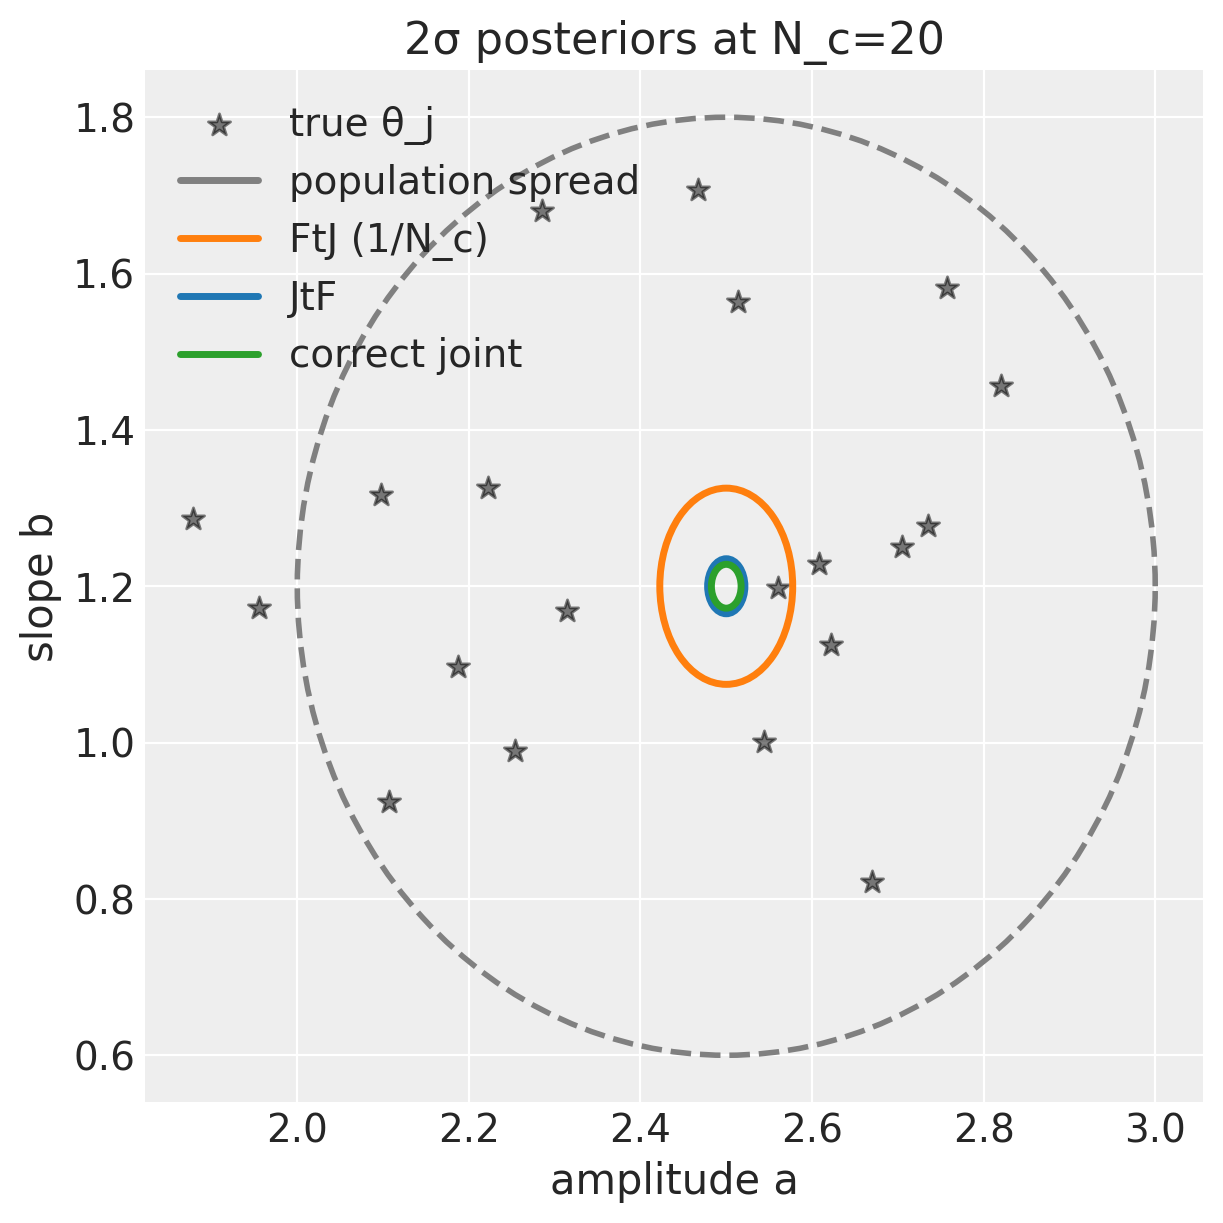

In [30]:
from matplotlib.patches import Ellipse
def cov_ellipse(ax, c, cov, n=2, **kw):
    v, V = np.linalg.eigh(cov); o = v.argsort()[::-1]; v, V = v[o], V[:, o]
    ang = np.degrees(np.arctan2(V[1, 0], V[0, 0])); ax.add_patch(Ellipse(c, *(2*n*np.sqrt(v)), angle=ang, fill=False, **kw))
XtX_inv = np.linalg.inv((np.column_stack([np.ones_like(log_r), -log_r])).T @ np.column_stack([np.ones_like(log_r), -log_r]))
fig, ax = plt.subplots(figsize=(6, 6)); c = mu_pop
ax.scatter(theta_true[:, 0], theta_true[:, 1], marker="*", s=70, color="k", alpha=0.5, label="true θ_j")
cov_ellipse(ax, c, np.diag(s_pop**2), color="gray", lw=2, ls="--"); cov_ellipse(ax, c, noise_dex**2*XtX_inv, color="tab:orange", lw=2.5)
cov_ellipse(ax, c, sigma_tilde_sq*XtX_inv, color="tab:blue", lw=2.5); cov_ellipse(ax, c, noise_dex**2/n_clusters*XtX_inv, color="tab:green", lw=2.5)
for lab, col in [("population spread", "gray"), ("FtJ (1/N_c)", "tab:orange"), ("JtF", "tab:blue"), ("correct joint", "tab:green")]:
    ax.plot([], [], color=col, lw=2.5, label=lab)
ax.set_xlabel("amplitude a"); ax.set_ylabel("slope b"); ax.set_title("2σ posteriors at N_c=20"); ax.legend(); plt.show()

/var/folders/y9/g2jj3nys17lfz6hmth5_mpth0000gn/T/ipykernel_74741/1602458939.py:8: UserWarning: The figure layout has changed to tight
  ax[1].set_xlabel("N_c"); ax[1].set_ylabel("ratio"); ax[1].set_title("FtJ is √N_c too wide (≈19× at N_c=376)"); ax[1].legend(); plt.tight_layout(); plt.show()


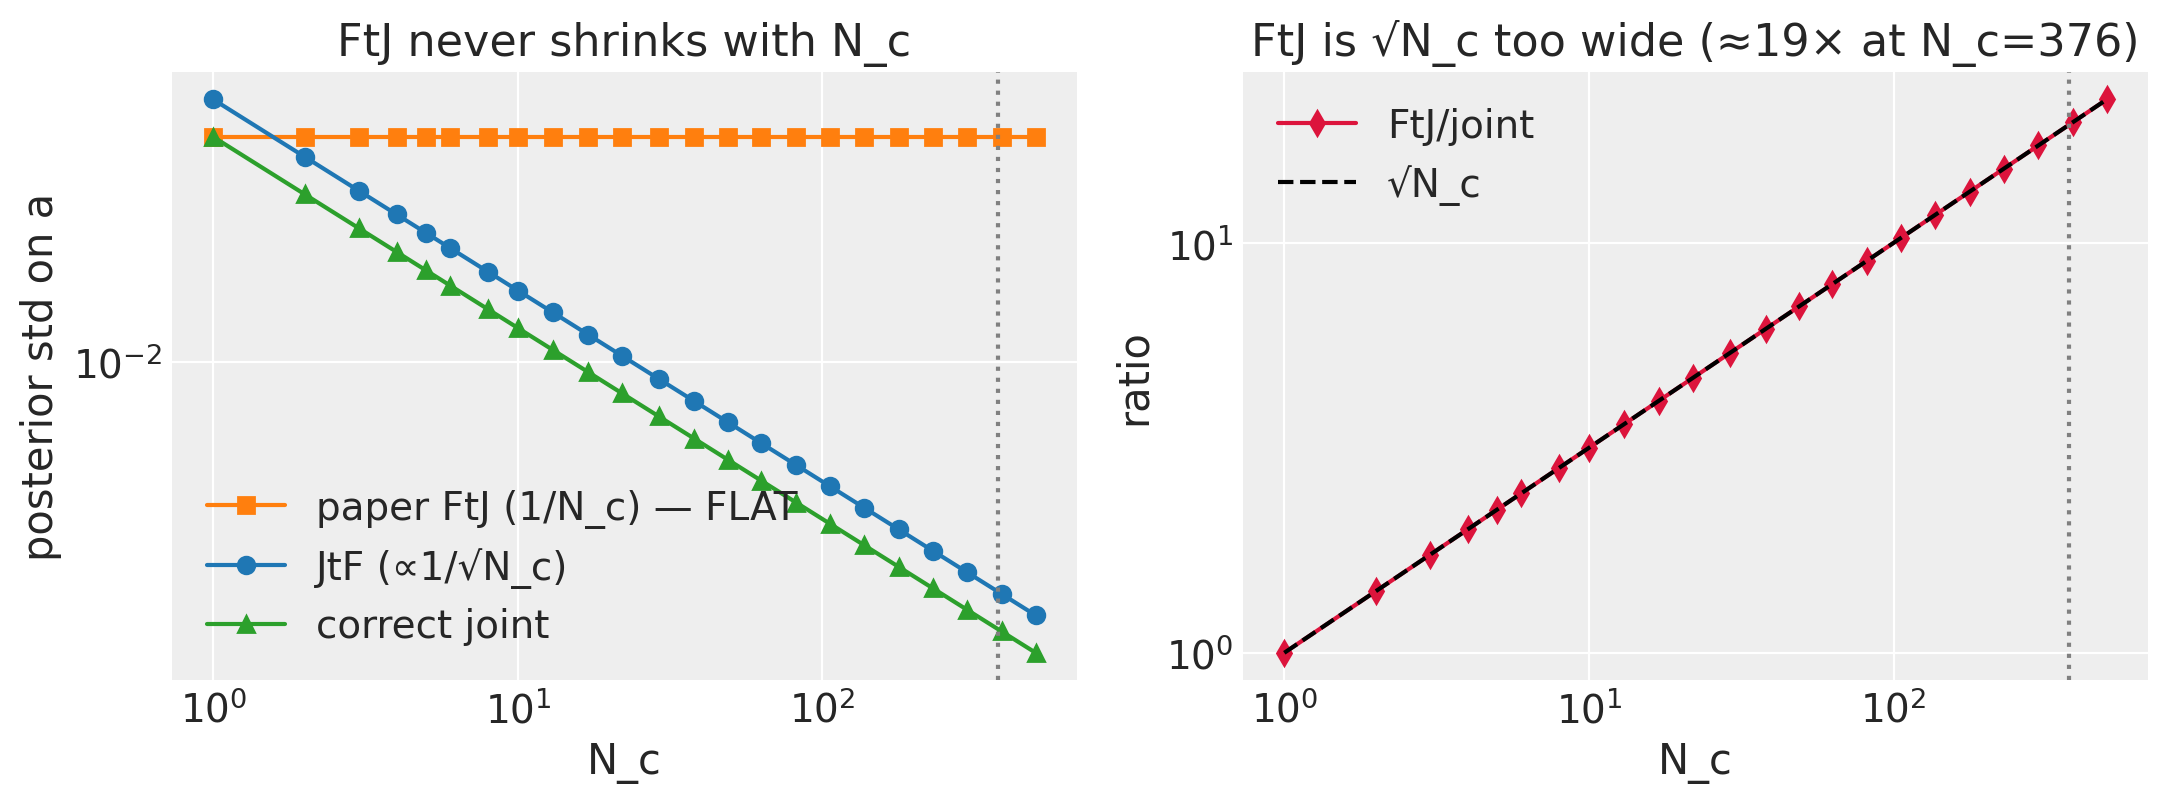

In [31]:
w0 = np.sqrt(XtX_inv[0, 0]); Nc = np.unique(np.round(np.logspace(0, 2.7, 25)).astype(int))
W_JtF = np.sqrt(np.pi/2)*noise_dex*w0/np.sqrt(Nc); W_jnt = noise_dex*w0/np.sqrt(Nc); W_FtJ = noise_dex*w0*np.ones_like(Nc, float)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].loglog(Nc, W_FtJ, "s-", color="tab:orange", label="paper FtJ (1/N_c) — FLAT"); ax[0].loglog(Nc, W_JtF, "o-", color="tab:blue", label="JtF (∝1/√N_c)")
ax[0].loglog(Nc, W_jnt, "^-", color="tab:green", label="correct joint"); ax[0].axvline(376, color="gray", ls=":")
ax[0].set_xlabel("N_c"); ax[0].set_ylabel("posterior std on a"); ax[0].set_title("FtJ never shrinks with N_c"); ax[0].legend()
ax[1].loglog(Nc, W_FtJ/W_jnt, "d-", color="crimson", label="FtJ/joint"); ax[1].loglog(Nc, np.sqrt(Nc), "k--", label="√N_c"); ax[1].axvline(376, color="gray", ls=":")
ax[1].set_xlabel("N_c"); ax[1].set_ylabel("ratio"); ax[1].set_title("FtJ is √N_c too wide (≈19× at N_c=376)"); ax[1].legend(); plt.tight_layout(); plt.show()

In [62]:
print(meas["JtF"])

[np.float64(0.02156661903437954), np.float64(0.01064120243206726), np.float64(0.005433184350428708)]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


...

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


JtF = 0.005461121761487232
FtJ = 0.03874414217292698
joint = 0.00433180563837462
FtJ/JtF =  7.09453915606814
FtJ/joint =  8.944109086912901


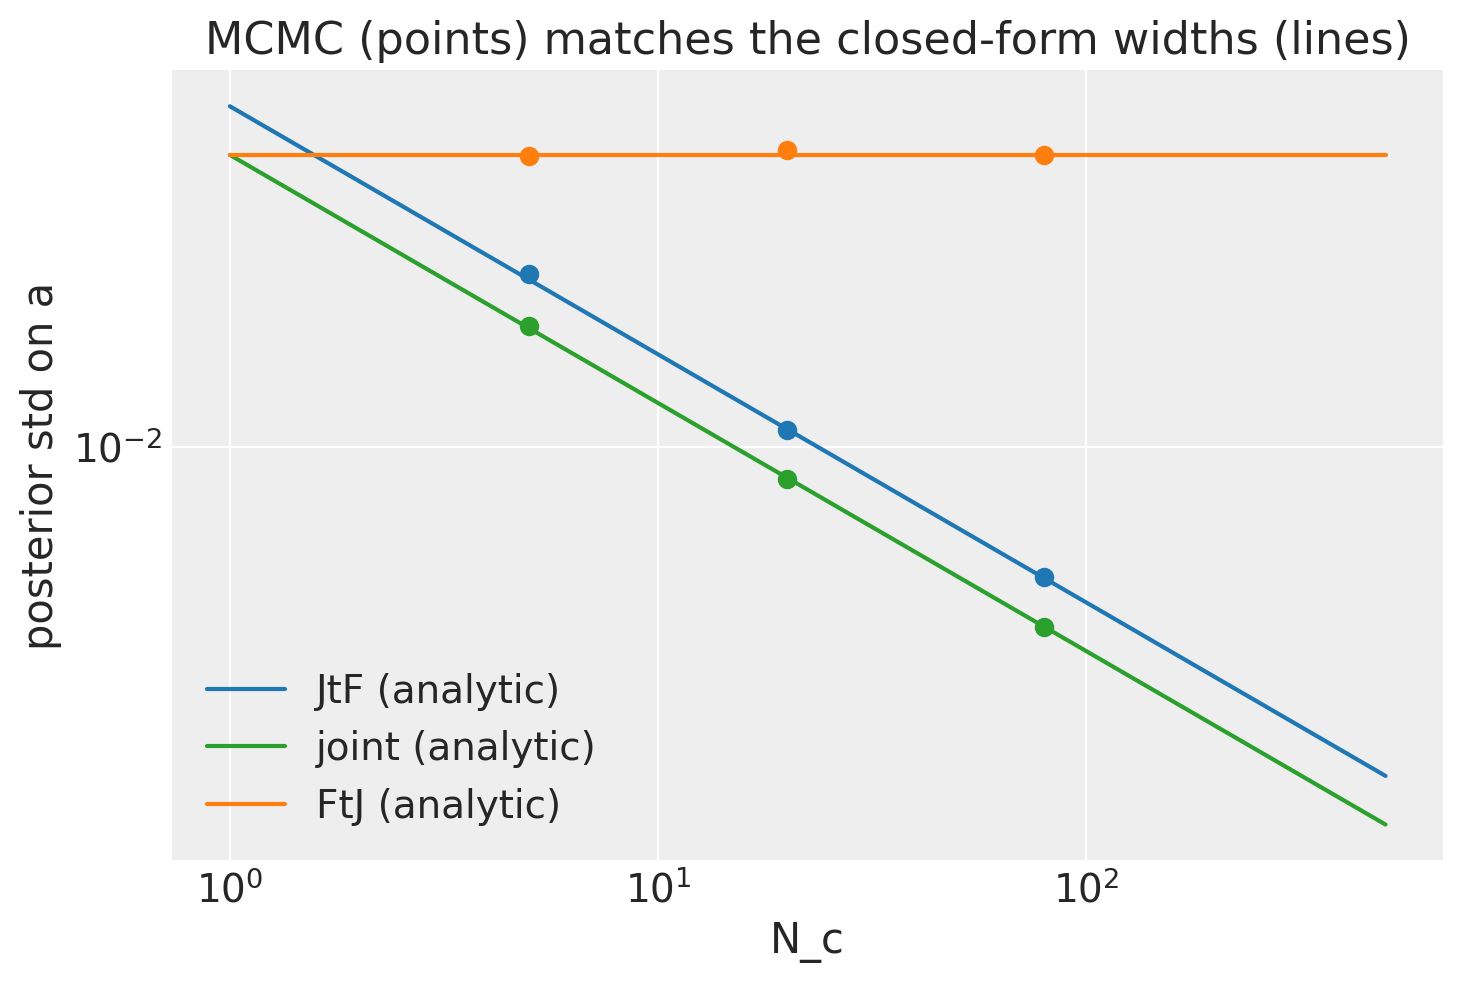

In [ ]:
meas = {"JtF": [], "joint": [], "FtJ": []}
Nc_test=[5,20,80]
for nc in Nc_test:
    trace_jtf, trace_ftj, trace_joint = fits(nc)
    w_jtf = trace_jtf.posterior["a"].values.flatten().std()
    w_joint = trace_joint.posterior["a"].values.flatten().std()
    w_ftj = trace_ftj.posterior["a"].values.flatten().std()
    meas["JtF"].append(w_jtf)
    meas["joint"].append(w_joint)
    meas["FtJ"].append(w_ftj)
plt.figure()
plt.loglog(Nc, W_JtF, "-", color="tab:blue", label="JtF (analytic)"); plt.loglog(Nc_test, meas["JtF"], "o", color="tab:blue")
plt.loglog(Nc, W_jnt, "-", color="tab:green", label="joint (analytic)"); plt.loglog(Nc_test, meas["joint"], "^", color="tab:green")
plt.loglog(Nc, W_FtJ, "-", color="tab:orange", label="FtJ (analytic)"); plt.loglog(Nc_test, meas["FtJ"], "s", color="tab:orange")
plt.xlabel("N_c"); plt.ylabel("posterior std on a"); plt.title("MCMC (points) matches the closed-form widths (lines)"); plt.legend(); plt.show()

In [ ]:
try:
    from colossus.cosmology import cosmology; from colossus.halo import profile_nfw
    cosmology.setCosmology("planck18"); nfw_r = 10**np.arange(0, 3, 0.1)
    def nfw_logSigma(theta):                         # theta = (log10 mass, concentration)
        h = profile_nfw.NFWProfile(M=10**theta[0], c=theta[1], z=0.0, mdef="vir")
        return np.log10(h.surfaceDensity(nfw_r))
    th0 = np.array([14.3, 5.0]); dex = 0.10
    # population of NFW clusters + noisy profiles
    Nc2 = 20; m = 14.3 + 0.10*np.random.randn(Nc2); cc = 5.0 + 0.7*np.random.randn(Nc2)
    P = np.array([nfw_logSigma([m[j], cc[j]]) + dex*np.random.randn(len(nfw_r)) for j in range(Nc2)])
    med = np.median(P, axis=0); st2 = (np.pi/2)*dex**2/Nc2
    inb = lambda t: 13.5 < t[0] < 15 and 1 < t[1] < 12
    lj = lambda t: (-0.5*np.sum((nfw_logSigma(t)-med)**2/st2)) if inb(t) else -np.inf            # JtF (median stack)
    lc = lambda t: (-0.5*np.sum((nfw_logSigma(t)[None]-P)**2/dex**2)) if inb(t) else -np.inf      # CORRECT joint (sum)
    s_j = run_mcmc(lj, args=(), start=th0, n_walkers=40, n_burn=300, n_steps=900)
    s_c = run_mcmc(lc, args=(), start=th0, n_walkers=40, n_burn=300, n_steps=900)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
    ax[0].plot(nfw_r, 10**nfw_logSigma(th0), "k-"); ax[0].set_xscale("log"); ax[0].set_yscale("log")
    ax[0].set_xlabel("r [kpc/h]"); ax[0].set_ylabel("NFW surface density"); ax[0].set_title("A real NFW profile (declines)")
    ax[1].scatter(s_c[::5, 0], s_c[::5, 1], s=5, alpha=0.2, marker="o", color="tab:green", label="correct joint")
    ax[1].scatter(s_j[::5, 0], s_j[::5, 1], s=5, alpha=0.2, marker="^", color="tab:blue", label="JtF")
    ax[1].plot(np.median(m), np.median(cc), "k*", ms=16, label="true median")
    ax[1].set_xlabel(r"$\log_{10} M$"); ax[1].set_ylabel("concentration c"); ax[1].set_title("NFW stacked posteriors (the CORRECT methods)"); ax[1].legend()
    plt.tight_layout(); plt.show()
    print("NFW stacked widths log10M:  JtF=%.3f  correct-joint=%.3f  (the buggy 1/N_c FtJ would be ~sqrt(N_c) wider)"
          % (s_j[:, 0].std(), s_c[:, 0].std()))
except Exception as e:
    print("Colossus not available; skipping NFW:", e)